# Sentinel-2 Feature Extraction

This notebook adds satellite information to the sampled BRP fields. The result is the final table used for model training.

## Setup and Load Fields

Connect to Google Earth Engine and load the field sample from the previous notebook.

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import ee
import geemap
import matplotlib.pyplot as plt

EE_PROJECT_ID = "flash-district-432315-q2"
SAMPLED_FIELDS_PATH = "../data/sampled_fields.gpkg"
EXPORT_DIR = Path("../data/EarthEngineExports")
FIELD_FEATURES_PATH = "../data/field_features.csv"

START_DATE = "2025-04-01"
END_DATE = "2025-11-01"

pd.set_option("display.max_columns", None)

# TODO: this has to be run with an Earth Engine account logged in.
ee.Authenticate(auth_mode="localhost")
ee.Initialize(project=EE_PROJECT_ID)

sampled_fields = gpd.read_file(SAMPLED_FIELDS_PATH)
sampled_fields = sampled_fields.to_crs("EPSG:4326")

print("Sampled fields:", len(sampled_fields))
print("CRS:", sampled_fields.crs)

display(sampled_fields["crop_class"].value_counts())


Sampled fields: 3103
CRS: EPSG:4326


crop_class
Grass         800
Potato        800
Maize         800
Sugar beet    297
Onion         164
Wheat         131
Barley        111
Name: count, dtype: int64

## Build the Sentinel-2 Image Collection

Use Sentinel-2 images from the 2025 growing season, remove cloudy pixels, and calculate NDVI and NDWI.

In [2]:
fields_for_ee = sampled_fields.reset_index()
fields_for_ee = fields_for_ee.rename(columns={"index": "field_id"})
fields_for_ee = fields_for_ee[["field_id", "crop_class", "area_ha", "geometry"]]

bounds = sampled_fields.total_bounds
min_lon = float(bounds[0])
min_lat = float(bounds[1])
max_lon = float(bounds[2])
max_lat = float(bounds[3])
field_bounds = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])

s2_sr = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
s2_sr = s2_sr.filterDate(START_DATE, END_DATE)
s2_sr = s2_sr.filterBounds(field_bounds)
s2_sr = s2_sr.filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 60))

s2_clouds = ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
s2_clouds = s2_clouds.filterDate(START_DATE, END_DATE)
s2_clouds = s2_clouds.filterBounds(field_bounds)

join = ee.Join.saveFirst("clouds")
join_filter = ee.Filter.equals(leftField="system:index", rightField="system:index")
joined = join.apply(s2_sr, s2_clouds, join_filter)
joined = ee.ImageCollection(joined).filter(ee.Filter.notNull(["clouds"]))

def mask_clouds(image):
    clouds = ee.Image(image.get("clouds"))
    cloud_probability = clouds.select("probability")
    good_pixels = cloud_probability.lt(40)
    image = image.updateMask(good_pixels)
    return image.copyProperties(image, ["system:time_start", "CLOUDY_PIXEL_PERCENTAGE"])

def add_indices(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")
    image = image.addBands(ndvi)
    image = image.addBands(ndwi)
    return image.copyProperties(image, ["system:time_start", "CLOUDY_PIXEL_PERCENTAGE"])

# TODO: maybe add more satellite bands later. For now only NDVI and NDWI.
s2_collection = joined.map(mask_clouds)
s2_collection = s2_collection.map(add_indices)
s2_collection = s2_collection.select(["NDVI", "NDWI"])

print("Sentinel-2 images:", s2_collection.size().getInfo())


Sentinel-2 images: 44


## Test Extraction on 50 Fields

Before exporting everything, test the extraction on a small field sample.

In [3]:
def extract_stats(image_collection, field_collection):
    def one_image(image, old_results):
        image = ee.Image(image)
        old_results = ee.FeatureCollection(old_results)

        date = ee.Date(image.get("system:time_start")).format("YYYY-MM-dd")

        stats = image.reduceRegions(
            collection=field_collection,
            reducer=ee.Reducer.mean(),
            scale=10,
            tileScale=4,
        )

        def add_date(field):
            field = field.set("date", date)
            field = field.set("image_id", image.get("system:index"))
            field = field.set("cloudy_pixel_percentage", image.get("CLOUDY_PIXEL_PERCENTAGE"))
            return field

        stats = stats.map(add_date)
        return old_results.merge(stats)

    empty = ee.FeatureCollection([])
    return ee.FeatureCollection(image_collection.iterate(one_image, empty))

def feature_collection_to_df(feature_collection):
    # This is a small workaround because geemap.ee_to_df gave an error with my pandas version.
    simple_table = feature_collection.map(lambda x: ee.Feature(None, x.toDictionary()))
    df = ee.data.computeFeatures({"expression": simple_table, "fileFormat": "PANDAS_DATAFRAME"})

    if "geo" in df.columns:
        df = df.drop(columns=["geo"])

    return df

# quick test first, not the full dataset yet
test_fields = fields_for_ee.sample(50, random_state=42)
test_fields_ee = geemap.geopandas_to_ee(test_fields, geodesic=False)

test_stats = extract_stats(s2_collection, test_fields_ee)
test_df = feature_collection_to_df(test_stats)

print("Test table shape:", test_df.shape)
display(test_df.head(10))


Test table shape: (2200, 8)


,NDVI,NDWI,area_ha,cloudy_pixel_percentage,crop_class,date,field_id,image_id
0,0.753975,-0.684786,4.876341,5.127916,Barley,2025-04-01,1161,20250401T104041_20250401T104123_T31UFT
1,0.268888,-0.417430,3.212789,5.127916,Potato,2025-04-01,1967,20250401T104041_20250401T104123_T31UFT
2,0.304123,-0.420265,1.129582,5.127916,Potato,2025-04-01,309,20250401T104041_20250401T104123_T31UFT
3,0.222809,-0.351429,4.257229,5.127916,Potato,2025-04-01,746,20250401T104041_20250401T104123_T31UFT
4,0.425644,-0.489118,2.082160,5.127916,Maize,2025-04-01,3099,20250401T104041_20250401T104123_T31UFT
5,0.426716,-0.485837,1.288783,5.127916,Maize,2025-04-01,903,20250401T104041_20250401T104123_T31UFT
6,0.868704,-0.763356,2.872394,5.127916,Grass,2025-04-01,1461,20250401T104041_20250401T104123_T31UFT
7,0.869403,-0.770559,3.375262,5.127916,Potato,2025-04-01,554,20250401T104041_20250401T104123_T31UFT
8,0.797608,-0.720826,2.399835,5.127916,Grass,2025-04-01,1034,20250401T104041_20250401T104123_T31UFT
9,0.313123,-0.459584,6.572387,5.127916,Sugar beet,2025-04-01,736,20250401T104041_20250401T104123_T31UFT


## Export All Fields in Batches

Earth Engine cannot handle all field polygons in one request, so export 100 fields at a time to Google Drive.

In [4]:
START_EXPORTS = False
BATCH_SIZE = 100
EXPORT_PREFIX = "brp_satellite_features_2025"
EXPORT_FOLDER = "EarthEngineExports"

EXPORT_COLUMNS = [
    "field_id",
    "crop_class",
    "area_ha",
    "date",
    "image_id",
    "cloudy_pixel_percentage",
    "NDVI",
    "NDWI",
]

#Work in progress note:
#Keep this False unless I really need to run the exports again.
#The CSV files are already downloaded in data/EarthEngineExports.
if START_EXPORTS == True:
    export_tasks = []
    number_of_fields = len(fields_for_ee)
    total_batches = number_of_fields // BATCH_SIZE + 1

    batch_number = 1
    for start in range(0, number_of_fields, BATCH_SIZE):
        end = start + BATCH_SIZE
        batch = fields_for_ee.iloc[start:end]

        batch_ee = geemap.geopandas_to_ee(batch, geodesic=False)
        batch_stats = extract_stats(s2_collection, batch_ee)

        batch_name = EXPORT_PREFIX + "_batch_" + str(batch_number).zfill(3)

        task = ee.batch.Export.table.toDrive(
            collection=batch_stats,
            description=batch_name,
            folder=EXPORT_FOLDER,
            fileNamePrefix=batch_name,
            fileFormat="CSV",
            selectors=EXPORT_COLUMNS,
        )

        task.start()
        export_tasks.append(task)
        print("Started", batch_name, "batch", batch_number, "of", total_batches)

        batch_number = batch_number + 1
else:
    print("Not starting exports right now.")
    print("Change START_EXPORTS to True only if the Drive exports need to be remade.")


Not starting exports right now.
Change START_EXPORTS to True only if the Drive exports need to be remade.


## Load Exports and Build the Final Feature Table

Load all exported batch CSVs, average NDVI and NDWI by month, and save one final row per field.

In [5]:
export_files = sorted(EXPORT_DIR.glob(EXPORT_PREFIX + "_batch_*.csv"))

if len(export_files) == 0:
    raise FileNotFoundError("No exported CSV files found")

all_tables = []
for file in export_files:
    one_table = pd.read_csv(file)
    all_tables.append(one_table)

satellite_rows = pd.concat(all_tables, ignore_index=True)

print("Export files:", len(export_files))
print("Satellite rows:", len(satellite_rows))
print("Fields covered:", satellite_rows["field_id"].nunique(), "/", len(sampled_fields))

month_names = {
    4: "apr",
    5: "may",
    6: "jun",
    7: "jul",
    8: "aug",
    9: "sep",
    10: "oct",
}

satellite_rows["date"] = pd.to_datetime(satellite_rows["date"])
satellite_rows["month"] = satellite_rows["date"].dt.month
satellite_rows["field_id"] = satellite_rows["field_id"].astype(int)
satellite_rows["NDVI"] = pd.to_numeric(satellite_rows["NDVI"], errors="coerce")
satellite_rows["NDWI"] = pd.to_numeric(satellite_rows["NDWI"], errors="coerce")

satellite_rows = satellite_rows[satellite_rows["month"].isin(month_names.keys())]

monthly = satellite_rows.groupby(["field_id", "month"], as_index=False)[["NDVI", "NDWI"]].mean()
features = monthly.pivot(index="field_id", columns="month", values=["NDVI", "NDWI"])

new_column_names = []
for old_name in features.columns:
    index_name = old_name[0].lower()
    month_number = old_name[1]
    month_text = month_names[month_number]
    new_column_names.append(index_name + "_" + month_text)

features.columns = new_column_names
features = features.reset_index()

ndvi_cols = []
ndwi_cols = []
for month in month_names.values():
    ndvi_cols.append("ndvi_" + month)
    ndwi_cols.append("ndwi_" + month)

for column in ndvi_cols + ndwi_cols:
    if column not in features.columns:
        features[column] = pd.NA

def get_peak_month(row, columns):
    values = row[columns]
    if values.isna().all():
        return pd.NA
    best_column = values.astype(float).idxmax()
    return best_column.split("_")[1]

features["ndvi_peak"] = features[ndvi_cols].max(axis=1)
features["ndvi_peak_month"] = features.apply(lambda row: get_peak_month(row, ndvi_cols), axis=1)
features["ndvi_season_mean"] = features[ndvi_cols].mean(axis=1)
features["ndvi_range"] = features[ndvi_cols].max(axis=1) - features[ndvi_cols].min(axis=1)

features["ndwi_peak"] = features[ndwi_cols].max(axis=1)
features["ndwi_peak_month"] = features.apply(lambda row: get_peak_month(row, ndwi_cols), axis=1)
features["ndwi_season_mean"] = features[ndwi_cols].mean(axis=1)
features["ndwi_range"] = features[ndwi_cols].max(axis=1) - features[ndwi_cols].min(axis=1)

field_table = sampled_fields.reset_index()
field_table = field_table.rename(columns={"index": "field_id"})

field_features = field_table.merge(features, on="field_id", how="inner")
field_features = field_features.drop(columns=["geometry"])
field_features.to_csv(FIELD_FEATURES_PATH, index=False)

print("Saved rows:", len(field_features))
print("Saved file:", FIELD_FEATURES_PATH)
display(field_features.head())


Export files: 32
Satellite rows: 136532
Fields covered: 3103 / 3103
Saved rows: 3103
Saved file: ../data/field_features.csv


,field_id,gewas,crop_class,area_ha,ndvi_apr,ndvi_may,ndvi_jun,ndvi_jul,ndvi_aug,ndvi_sep,ndvi_oct,ndwi_apr,ndwi_may,ndwi_jun,ndwi_jul,ndwi_aug,ndwi_sep,ndwi_oct,ndvi_peak,ndvi_peak_month,ndvi_season_mean,ndvi_range,ndwi_peak,ndwi_peak_month,ndwi_season_mean,ndwi_range
0,0,"Grasland, tijdelijk",Grass,0.766181,0.817539,0.647438,0.580305,0.444897,0.464195,0.643147,0.801593,-0.742776,-0.614275,-0.569561,-0.499303,-0.497035,-0.573292,-0.718762,0.817539,apr,0.628445,0.372642,-0.497035,aug,-0.602143,0.245741
1,1,"Gerst, zomer-",Barley,4.536244,0.464733,0.515721,0.295870,0.431314,0.796887,0.293842,0.383652,-0.489983,-0.507482,-0.396986,-0.456692,-0.707940,-0.345315,-0.424870,0.796887,aug,0.454574,0.503044,-0.345315,sep,-0.475610,0.362625
2,2,"Aardappelen, consumptie",Potato,2.130793,0.349438,0.361585,0.820149,0.871702,0.696163,0.359605,0.270849,-0.458962,-0.451197,-0.745965,-0.768131,-0.638192,-0.435534,-0.359532,0.871702,jul,0.532784,0.600853,-0.359532,oct,-0.551073,0.408600
3,3,"Mais, corncob mix",Maize,0.899990,0.337278,0.328379,0.661381,0.832881,0.743754,0.509124,0.423538,-0.409937,-0.400422,-0.606444,-0.764615,-0.667611,-0.501408,-0.480292,0.832881,jul,0.548048,0.504502,-0.400422,may,-0.547247,0.364193
4,4,"Uien, gele zaai-",Onion,3.651977,0.292880,0.304674,0.455917,0.549658,0.500220,0.349081,0.278926,-0.416159,-0.433493,-0.513710,-0.588000,-0.533164,-0.407066,-0.280463,0.549658,jul,0.390194,0.270732,-0.280463,oct,-0.453151,0.307537


## Plotting the crop curves

Plot one example field per crop class to see the seasonal NDVI pattern and to see if we can distuingish

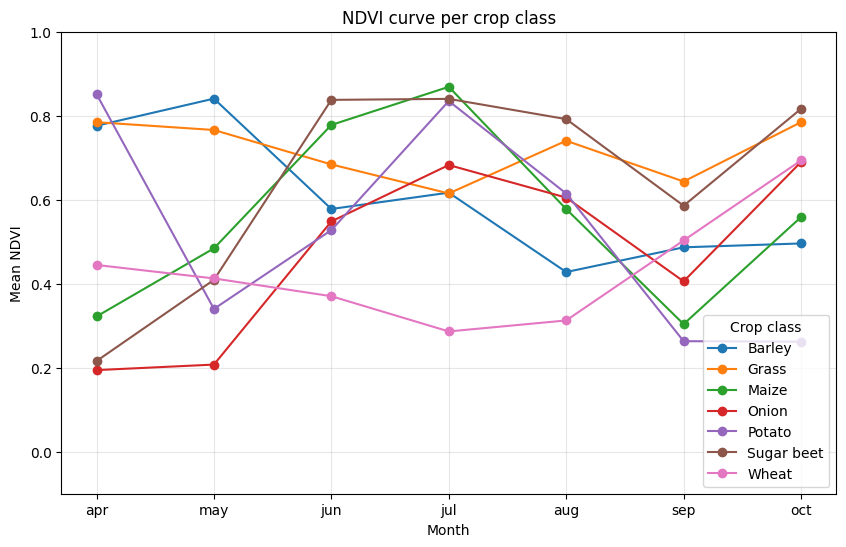

In [6]:
example_fields = field_features.dropna(subset=ndvi_cols, how="all")
example_fields = example_fields.groupby("crop_class", group_keys=False).sample(1, random_state=42)

plt.figure(figsize=(10, 6))

for index, row in example_fields.iterrows():
    y_values = row[ndvi_cols].astype(float)
    x_values = list(month_names.values())
    plt.plot(x_values, y_values, marker="o", label=row["crop_class"])

plt.title("NDVI curve per crop class")
plt.xlabel("Month")
plt.ylabel("Mean NDVI")
plt.ylim(-0.1, 1.0)
plt.grid(True, alpha=0.3)
plt.legend(title="Crop class")
plt.show()


As you can see, NDVI curves already show visible separation between crop classes, for example, grass stays relatively flat across the season, while potato shows a sharp peak in mid-summer. This suggests the model should be able to learn discriminative patterns from these seasonal signatures. That said, some classes (like wheat vs. barley, or maize vs. sugar beet in late season) look similar and will likely be harder to distinguish. Each line represents one example field per class, so the full dataset will give a clearer picture of the patterns.



## Feature Set Reflection

This first version uses NDVI and NDWI because they are simple, interpretable features that already capture useful crop-season patterns: NDVI tracks vegetation greenness, and NDWI gives a moisture-related signal. The crop-curve plot above shows that these two indices contain real signal, especially when their monthly pattern is used instead of only one date.

That said, NDVI and NDWI are a baseline feature set, not necessarily the best possible feature set. Some crops can look similar in these two indices, for example wheat versus barley, or maize versus sugar beet in parts of the season. A stronger next version could add more Sentinel-2 information such as raw spectral bands, red-edge bands, NDMI, EVI, SAVI, per-month standard deviation, percentiles, or more detailed time-series shape features.

For the presentation, the honest framing is: this model starts with two well-known vegetation indices to prove that seasonal satellite patterns can predict crop type. The results show useful separation, but adding more spectral and temporal features would probably improve difficult classes.
